Importar librerias

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import math
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import matplotlib.gridspec as gridspec
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import joblib
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

Cargar datos

In [3]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
df = pd.read_csv(url)

In [4]:
df.shape

(768, 9)

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [13]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [14]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


## 4. Valores cero sospechosos

En variables como `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI`, un valor de **0 no tiene sentido médico** — indican datos faltantes codificados como 0.

In [15]:
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_con_ceros:
    n_ceros = (df[col] == 0).sum()
    pct = n_ceros / len(df) * 100
    print(f'{col}: {n_ceros} ceros ({pct:.1f}%)')

Glucose: 5 ceros (0.7%)
BloodPressure: 35 ceros (4.6%)
SkinThickness: 227 ceros (29.6%)
Insulin: 374 ceros (48.7%)
BMI: 11 ceros (1.4%)


In [18]:

df[cols_con_ceros] = df[cols_con_ceros].replace(0, np.nan)

for col in cols_con_ceros:
    df[col].fillna(df[col].median(), inplace=True)

print('Valores nulos tras imputación:')
print(df.isnull().sum())

Valores nulos tras imputación:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


/tmp/ipykernel_4576/1946174676.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_4576/1946174676.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to u

## 5. Variable objetivo: Outcome

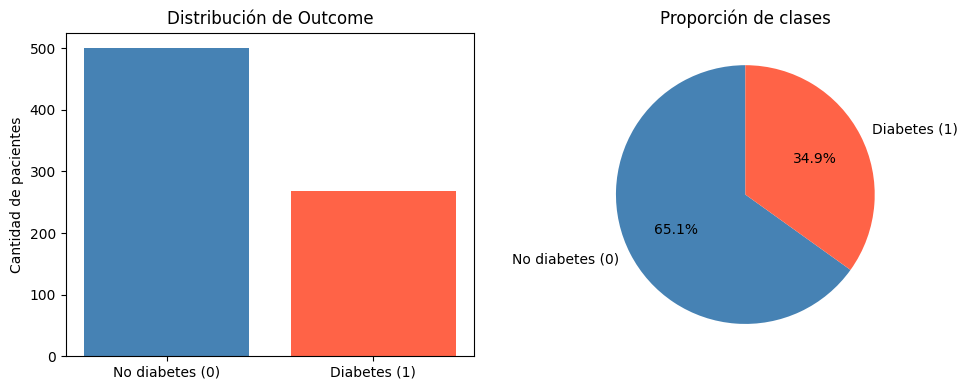

Outcome
0    500
1    268
Name: count, dtype: int64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['Outcome'].value_counts()
labels = ['No diabetes (0)', 'Diabetes (1)']

axes[0].bar(labels, counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribución de Outcome')
axes[0].set_ylabel('Cantidad de pacientes')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

print(counts)

## 6. Distribución de cada variable

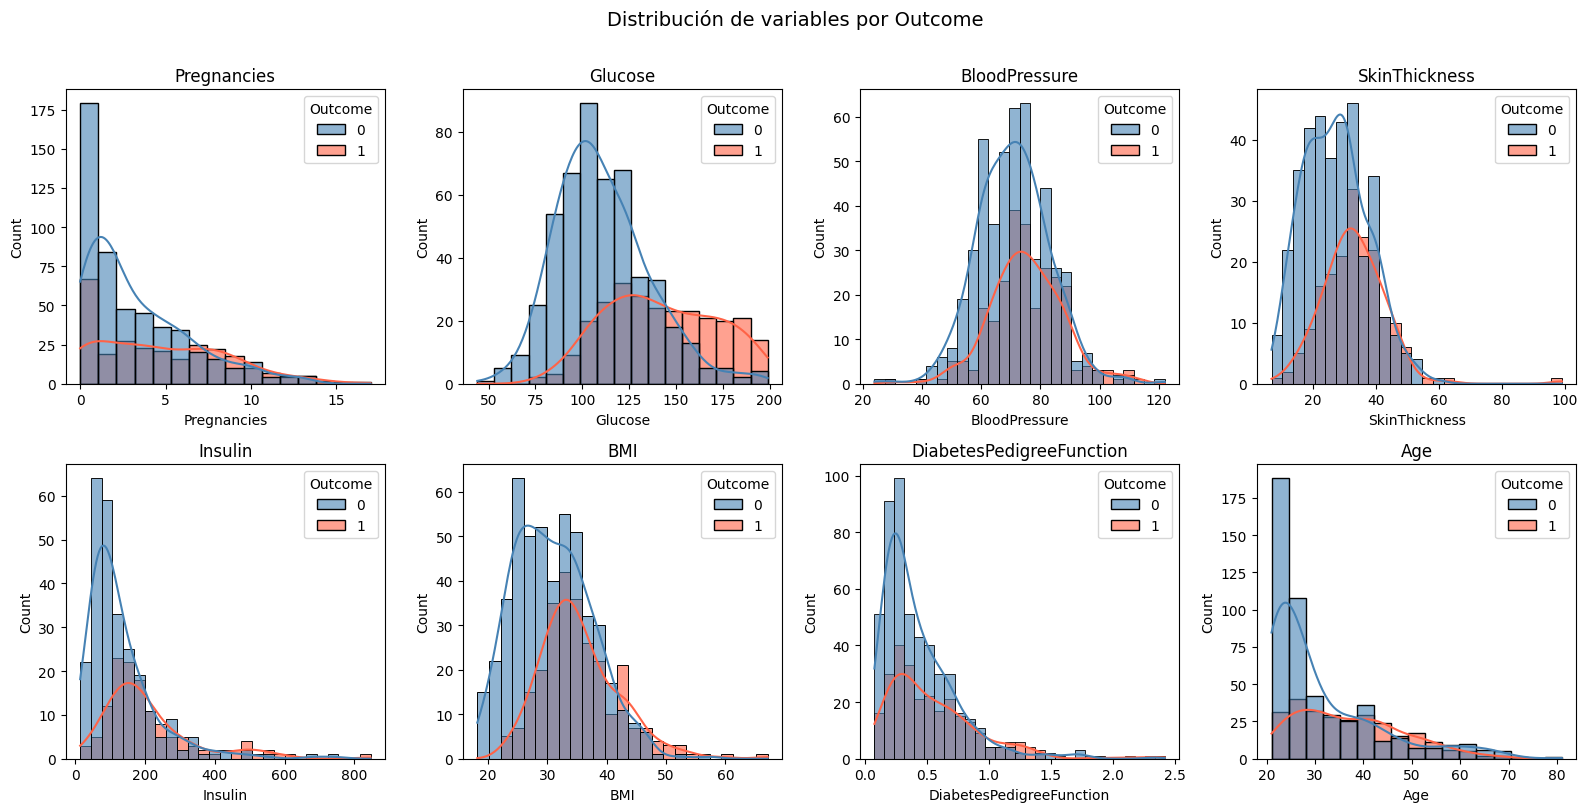

In [20]:
features = df.columns.drop('Outcome')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True,
                 ax=axes[i], palette=['steelblue', 'tomato'], alpha=0.6)
    axes[i].set_title(col)

plt.suptitle('Distribución de variables por Outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()




/tmp/ipykernel_4576/3721905279.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, ax=axes[i],
/tmp/ipykernel_4576/3721905279.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No diabetes', 'Diabetes'])
/tmp/ipykernel_4576/3721905279.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, ax=axes[i],
/tmp/ipykernel_4576/3721905279.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No diabetes', 'Diabetes'])
/tmp/ipyke

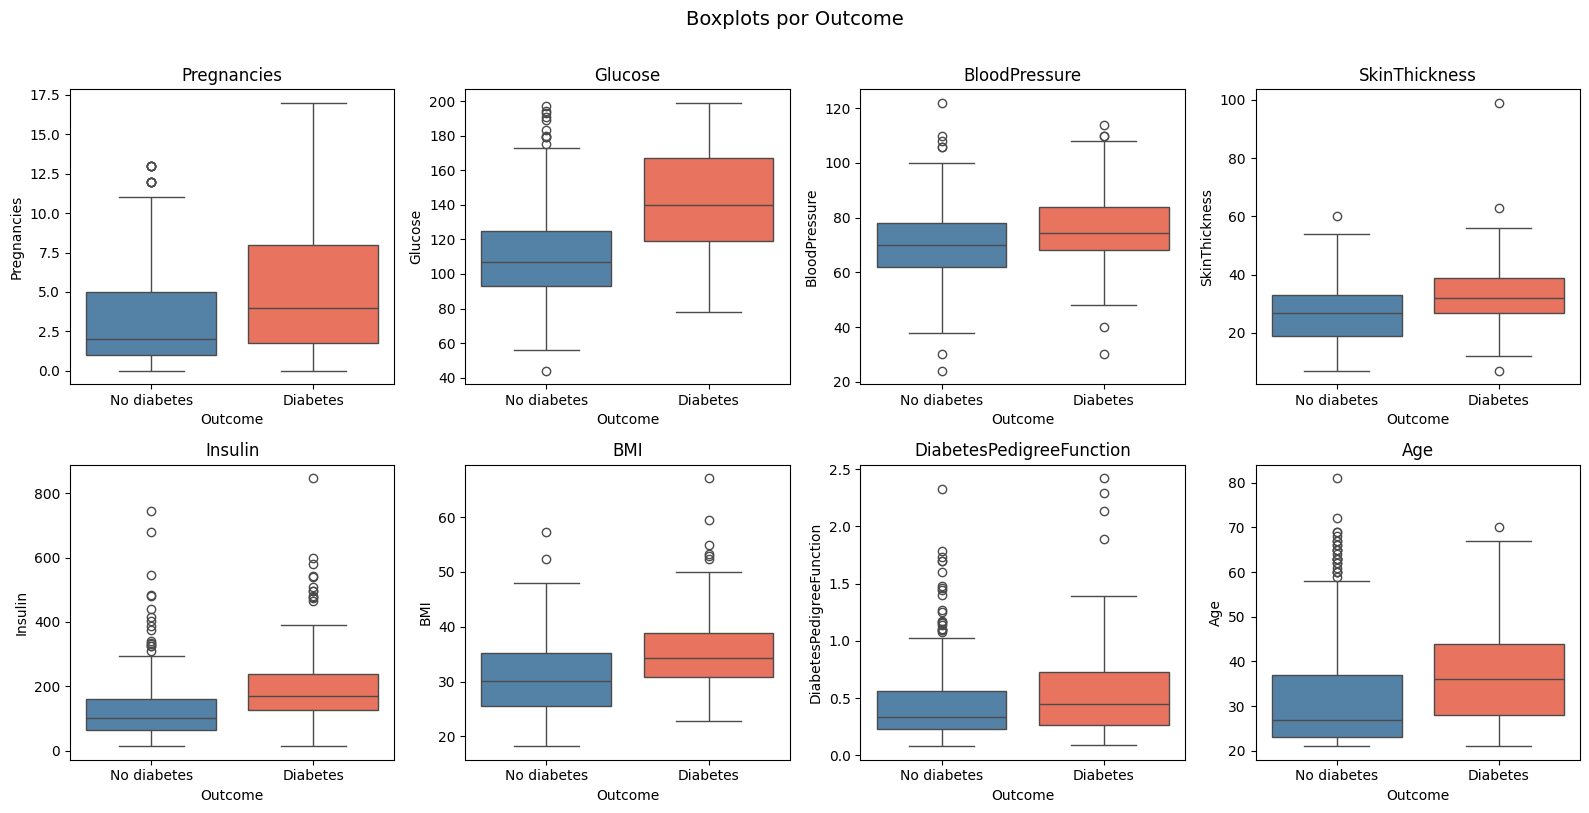

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='Outcome', y=col, ax=axes[i],
                palette=['steelblue', 'tomato'])
    axes[i].set_title(col)
    axes[i].set_xticklabels(['No diabetes', 'Diabetes'])

plt.suptitle('Boxplots por Outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

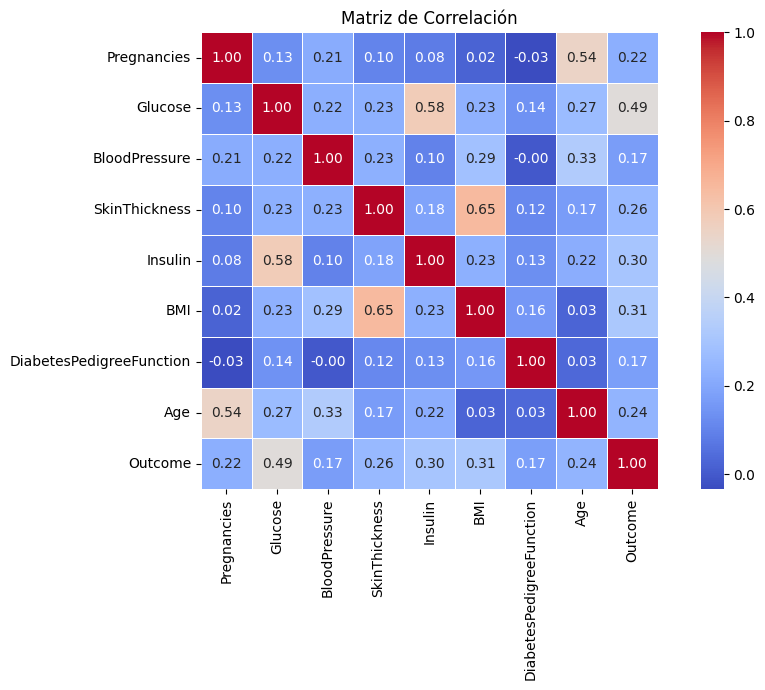

In [22]:
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

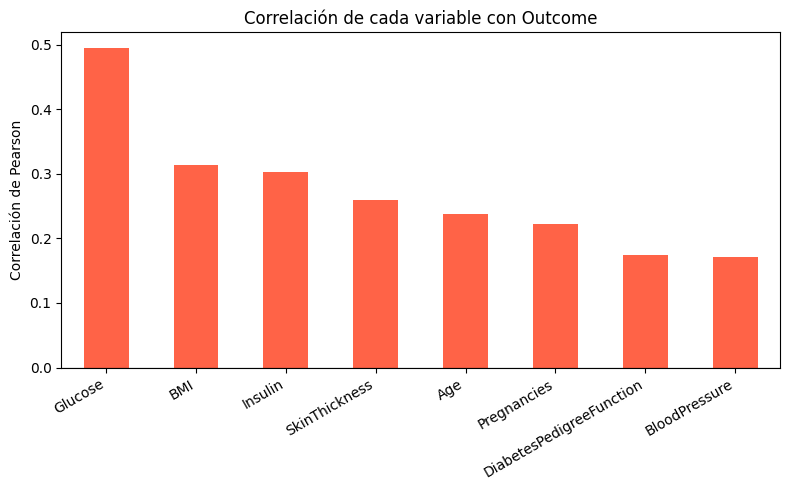

Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64

In [24]:
corr_outcome = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_outcome]
corr_outcome.plot(kind='bar', color=colors)
plt.title('Correlación de cada variable con Outcome')
plt.ylabel('Correlación de Pearson')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

corr_outcome

In [26]:

X = df.drop(columns='Outcome')
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} filas')
print(f'Test:  {X_test.shape[0]} filas')
print(f'\nProporción Outcome en train:\n{y_train.value_counts(normalize=True).round(2)}')
print(f'\nProporción Outcome en test:\n{y_test.value_counts(normalize=True).round(2)}')

Train: 614 filas
Test:  154 filas

Proporción Outcome en train:
Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64

Proporción Outcome en test:
Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64


## Conclusiones del EDA

- El dataset tiene **768 pacientes** y **9 variables**, todas numéricas.
- **No hay nulos reales**, pero `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI` tenían ceros que no tienen sentido médico. cambiados con la mediana.
- Las clases están **desbalanceadas**: 65% negativo, 35% positivo.
- Las variables con **mayor correlación con Outcome** son: `Glucose`, `BMI`, `Age` y `DiabetesPedigreeFunction`.
- `Insulin` y `SkinThickness` tienen mucha variabilidad y posibles outliers.
- El dataset se dividió en **80% train / 20% test** con estratificación.

In [28]:
criterios = ['gini', 'entropy', 'log_loss']
resultados = {}

for criterio in criterios:
    modelo = DecisionTreeClassifier(criterion=criterio, random_state=42)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados[criterio] = {'modelo': modelo, 'y_pred': y_pred, 'accuracy': acc}
    print(f'Criterio: {criterio:10s} | Accuracy: {acc:.4f}')

Criterio: gini       | Accuracy: 0.6558
Criterio: entropy    | Accuracy: 0.7403
Criterio: log_loss   | Accuracy: 0.7403


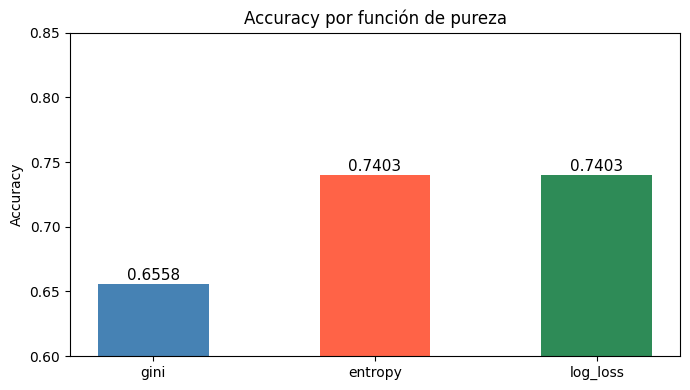

In [29]:
nombres = list(resultados.keys())
accuracies = [resultados[c]['accuracy'] for c in nombres]

plt.figure(figsize=(7, 4))
bars = plt.bar(nombres, accuracies, color=['steelblue', 'tomato', 'seagreen'], width=0.5)
plt.ylim(0.6, 0.85)
plt.ylabel('Accuracy')
plt.title('Accuracy por función de pureza')

for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [30]:
for criterio in criterios:
    print(f'\n--- Criterio: {criterio} ---')
    print(classification_report(y_test, resultados[criterio]['y_pred'],
                                 target_names=['No diabetes', 'Diabetes']))


--- Criterio: gini ---
              precision    recall  f1-score   support

 No diabetes       0.72      0.78      0.75       100
    Diabetes       0.51      0.43      0.46        54

    accuracy                           0.66       154
   macro avg       0.61      0.60      0.61       154
weighted avg       0.64      0.66      0.65       154


--- Criterio: entropy ---
              precision    recall  f1-score   support

 No diabetes       0.81      0.79      0.80       100
    Diabetes       0.62      0.65      0.64        54

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154


--- Criterio: log_loss ---
              precision    recall  f1-score   support

 No diabetes       0.81      0.79      0.80       100
    Diabetes       0.62      0.65      0.64        54

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72      

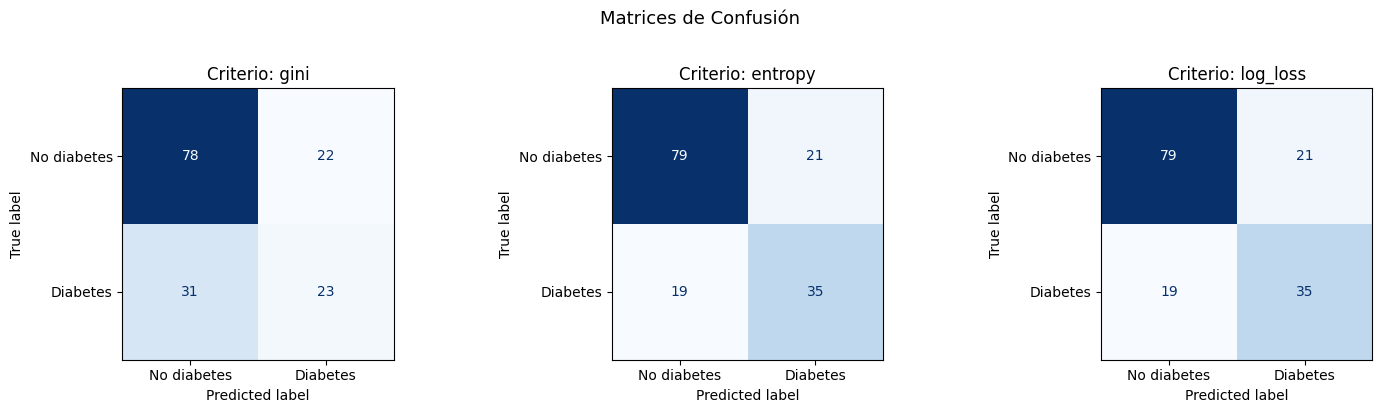

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, criterio in zip(axes, criterios):
    cm = confusion_matrix(y_test, resultados[criterio]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No diabetes', 'Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Criterio: {criterio}')

plt.suptitle('Matrices de Confusión', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Mejor criterio: entropy (accuracy = 0.7403)


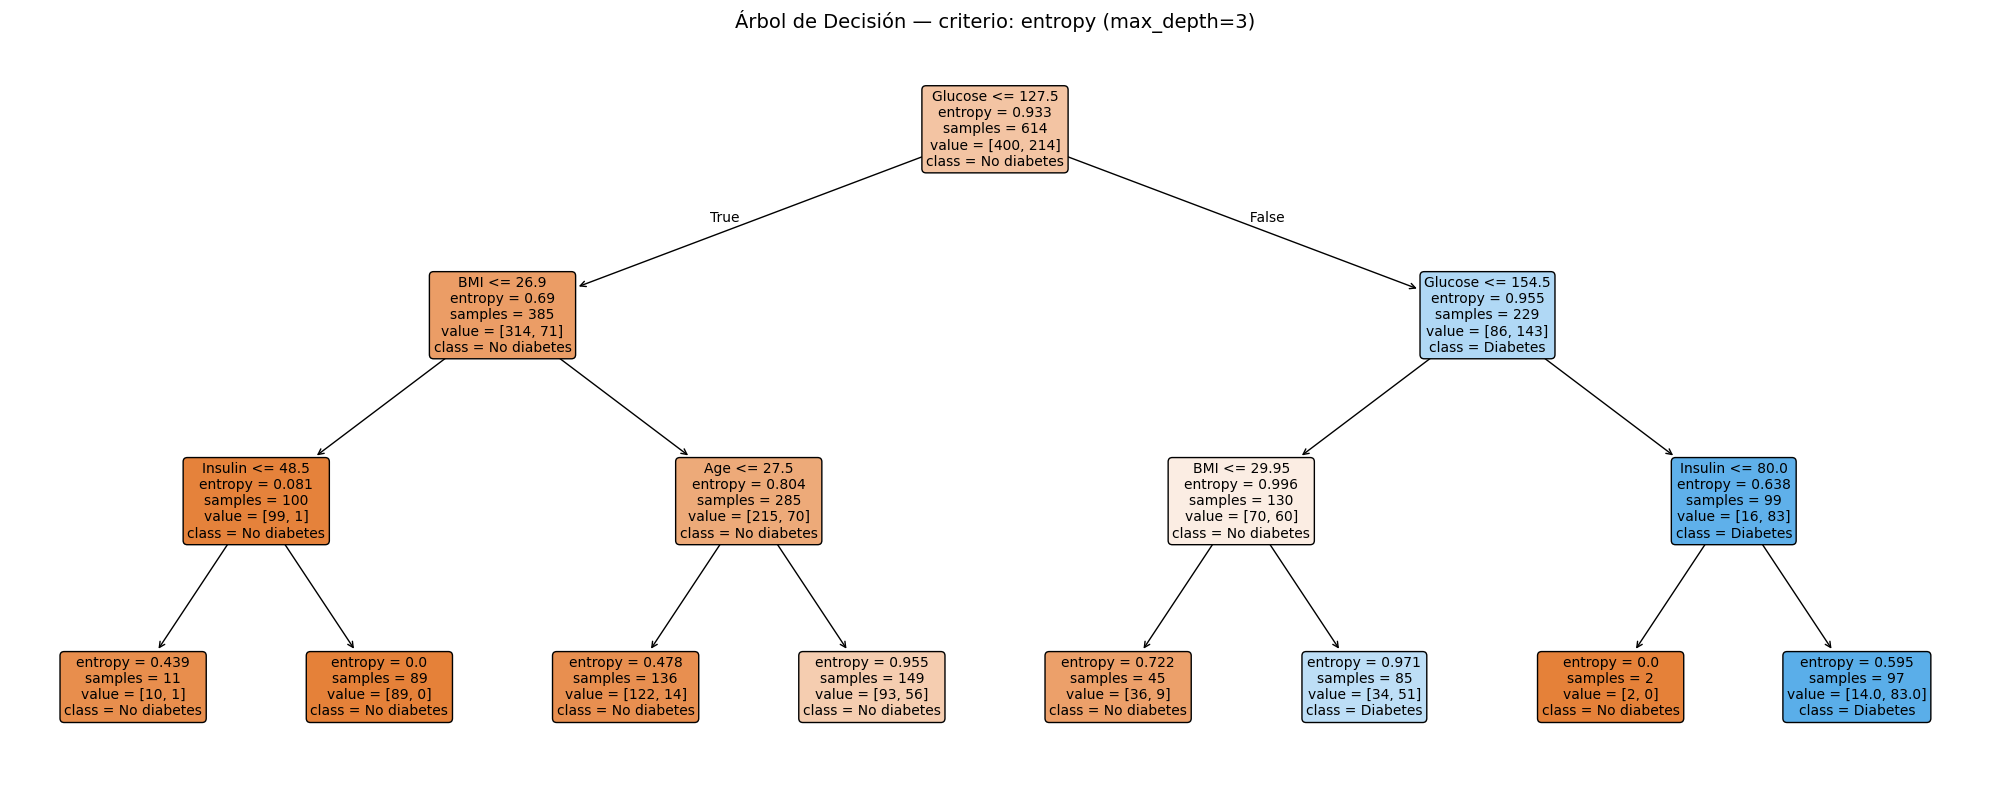

In [34]:

mejor_criterio = max(resultados, key=lambda c: resultados[c]['accuracy'])
print(f'Mejor criterio: {mejor_criterio} (accuracy = {resultados[mejor_criterio]["accuracy"]:.4f})')

arbol_viz = DecisionTreeClassifier(criterion=mejor_criterio, max_depth=3, random_state=42)
arbol_viz.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(
    arbol_viz,
    feature_names=X.columns.tolist(),
    class_names=['No diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f'Árbol de Decisión — criterio: {mejor_criterio} (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()

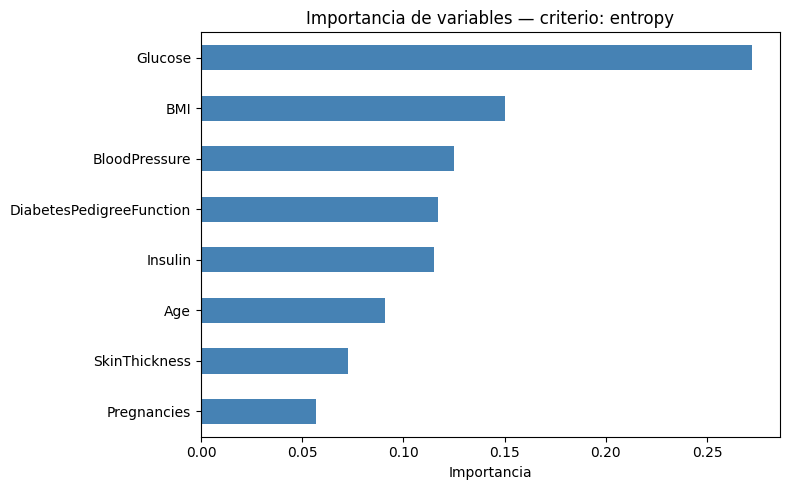

In [35]:
mejor_modelo = resultados[mejor_criterio]['modelo']

importancias = pd.Series(
    mejor_modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importancias.plot(kind='barh', color='steelblue')
plt.title(f'Importancia de variables — criterio: {mejor_criterio}')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## Conclusiones

- Los tres criterios dan resultados similares en este dataset.
- **`Glucose`** es la variable más importante para el árbol, seguida de `BMI` y `Age` — consistente con el EDA.


In [ ]:
import os

os.makedirs('./data/raw', exist_ok=True)
os.makedirs('./data/processed', exist_ok=True)
df.to_csv('./data/raw/diabetes_clean.csv', index=False)